# JSON Inputs Setup

This notebook loads two JSON files into separate variables:

- `json_edit_data` from `JSON_Edit/ASTIDC-STAN-HE-MPD-RHP1-M-M-0001.json`
- `json_whole_model_data` from `JSON Whole Model/ASTIDC-STAN-HE-MPD-RHP1-M-M-0001.json`

Then it compares renamed objects and prints a grouped comparison table.

In [7]:
import json
from pathlib import Path

file_name = "ASTIDC-STAN-HE-MPD-RHP1-M-M-0001.json"

# Resolve workspace root whether current working directory is workspace root or notebook folder
base_dir = Path.cwd()
if not (base_dir / "JSON_Edit").exists() and (base_dir.parent / "JSON_Edit").exists():
    base_dir = base_dir.parent

json_edit_path = base_dir / "JSON_Edit" / file_name
json_whole_model_path = base_dir / "JSON Whole Model" / file_name

with json_edit_path.open("r", encoding="utf-8") as f:
    json_edit_data = json.load(f)

with json_whole_model_path.open("r", encoding="utf-8") as f:
    json_whole_model_data = json.load(f)

print(f"Loaded JSON_Edit file: {json_edit_path}")
print(f"Loaded JSON Whole Model file: {json_whole_model_path}")

Loaded JSON_Edit file: c:\Git\APS-IFC\JSON_Edit\ASTIDC-STAN-HE-MPD-RHP1-M-M-0001.json
Loaded JSON Whole Model file: c:\Git\APS-IFC\JSON Whole Model\ASTIDC-STAN-HE-MPD-RHP1-M-M-0001.json


In [8]:
import pandas as pd
from IPython.display import HTML, display


def _normalize(value):
    if value is None:
        return ""
    return str(value).strip()


def _build_match_key(item):
    dbid = item.get("DbId")
    external_id = _normalize(item.get("ExternalId"))

    if dbid is not None and external_id:
        return f"DbId:{dbid}|ExternalId:{external_id}"
    if dbid is not None:
        return f"DbId:{dbid}"
    if external_id:
        return f"ExternalId:{external_id}"

    return None


def _find_name_property(item):
    empty = {"category": "", "displayName": "", "value": ""}
    props = item.get("Properties", [])
    if not isinstance(props, list):
        return empty

    for prop in props:
        if not isinstance(prop, dict):
            continue
        if _normalize(prop.get("displayName")).lower() == "name":
            return {
                "category": _normalize(prop.get("category")),
                "displayName": _normalize(prop.get("displayName")),
                "value": _normalize(prop.get("value")),
            }
    return empty


# Build lookup maps by stable object identity
whole_map = {}
for item in json_whole_model_data:
    if isinstance(item, dict):
        key = _build_match_key(item)
        if key:
            whole_map[key] = item

edit_map = {}
for item in json_edit_data:
    if isinstance(item, dict):
        key = _build_match_key(item)
        if key:
            edit_map[key] = item


# Compare renamed objects
rows = []
for key in sorted(set(whole_map.keys()) & set(edit_map.keys())):
    whole_item = whole_map[key]
    edit_item = edit_map[key]

    whole_name = _normalize(whole_item.get("Name"))
    edit_name = _normalize(edit_item.get("Name"))

    if whole_name != edit_name and (whole_name or edit_name):
        whole_name_prop = _find_name_property(whole_item)
        edit_name_prop = _find_name_property(edit_item)

        rows.append(
            {
                "Existing Model Name": whole_name,
                "Edited Name": edit_name,
                "Property Category": whole_name_prop.get("category", "") or edit_name_prop.get("category", ""),
                "Property DisplayName": whole_name_prop.get("displayName", "") or edit_name_prop.get("displayName", ""),
            }
        )

comparison_df = pd.DataFrame(rows)
raw_total_changed_elements = len(comparison_df)

# Keep grouped data preparation for downstream chart/analysis, without rendering the old Changed Names Comparison table.
if raw_total_changed_elements > 0:
    comparison_df = (
        comparison_df.groupby(
            [
                "Existing Model Name",
                "Edited Name",
                "Property Category",
                "Property DisplayName",
            ],
            dropna=False,
            as_index=False,
        )
        .size()
        .rename(columns={"size": "Count"})
        .sort_values(["Count", "Existing Model Name"], ascending=[False, True], kind="stable")
        .reset_index(drop=True)
    )

print(f"Total changed model elements: {raw_total_changed_elements}")
print("Changed Names Comparison table removed. Use the 'Changed IFC Names Comparison' section below.")

Total changed model elements: 3996
Changed Names Comparison table removed. Use the 'Changed IFC Names Comparison' section below.


## Changed Names Comparison

This section shows a second comparison table using the EPD-style grouping logic:
- Group by Edited Name
- Merge duplicate Existing Model Name values with counts
- Include Count per Edited Name

In [9]:
import pandas as pd
from IPython.display import HTML, display


def _format_existing_names(values):
    normalized_values = [_normalize(v) for v in values if _normalize(v)]
    if not normalized_values:
        return ""

    counts = {}
    for name in normalized_values:
        counts[name] = counts.get(name, 0) + 1

    return "<br>".join([f"{name} (x{counts[name]})" for name in sorted(counts)])


def _truncate_html_lines(value, max_lines=10):
    lines = [line for line in str(value).split("<br>") if line]
    if len(lines) <= max_lines:
        return value
    remaining = len(lines) - max_lines
    return "<br>".join(lines[:max_lines] + [f"... ({remaining} more)"])


if "rows" not in globals() or len(rows) == 0:
    print("No renamed objects found between JSON Whole Model and JSON_Edit.")
else:
    changed_ifc_df = pd.DataFrame(rows)

    # EPD-style grouping: summarize duplicates by Edited Name.
    changed_ifc_df = (
        changed_ifc_df.groupby("Edited Name", dropna=False, as_index=False)
        .agg(
            {
                "Existing Model Name": _format_existing_names,
                "Property Category": "first",
                "Property DisplayName": "first",
            }
        )
    )

    edited_name_counts = (
        pd.DataFrame(rows)
        .groupby("Edited Name", dropna=False)
        .size()
        .rename("Count")
        .reset_index()
    )
    changed_ifc_df = changed_ifc_df.merge(edited_name_counts, on="Edited Name", how="left")

    changed_ifc_df = changed_ifc_df[
        [
            "Existing Model Name",
            "Edited Name",
            "Property Category",
            "Property DisplayName",
            "Count",
        ]
    ]

    # For Edited Name == "A", keep only first 10 Existing Model Name lines.
    is_a_row = changed_ifc_df["Edited Name"].astype(str).str.strip().eq("A")
    changed_ifc_df.loc[is_a_row, "Existing Model Name"] = changed_ifc_df.loc[
        is_a_row, "Existing Model Name"
    ].apply(lambda v: _truncate_html_lines(v, max_lines=10))

    max_rows_to_show = 30
    if len(changed_ifc_df) > max_rows_to_show:
        top_rows = changed_ifc_df.head(max_rows_to_show).copy()
        bottom_row = changed_ifc_df.tail(1).copy()

        separator_row = {col: "..." for col in changed_ifc_df.columns}
        if "Count" in separator_row:
            separator_row["Count"] = "..."

        changed_ifc_table_to_show = pd.concat(
            [top_rows, pd.DataFrame([separator_row]), bottom_row],
            ignore_index=True,
        )
        second_table_message = f"Showing top {max_rows_to_show} row(s), a separator, and the last row."
    else:
        changed_ifc_table_to_show = changed_ifc_df.head(max_rows_to_show)
        second_table_message = f"Showing {len(changed_ifc_table_to_show)} row(s) (limit: {max_rows_to_show})."

    print(second_table_message)

    changed_ifc_html_table = changed_ifc_table_to_show.to_html(index=False, justify="left", escape=False)
    changed_ifc_html_block = f"""
    <div style='text-align:left; font-weight:600; margin:16px 0 6px 0;'>Changed Names Comparison</div>
    <style>
      table.dataframe {{
        margin-left: 0;
        margin-right: auto;
        border-collapse: collapse;
      }}
      table.dataframe th, table.dataframe td {{
        text-align: left !important;
        vertical-align: top;
        padding: 4px 8px;
      }}
    </style>
    {changed_ifc_html_table}
    """
    display(HTML(changed_ifc_html_block))

Showing top 30 row(s), a separator, and the last row.


Existing Model Name,Edited Name,Property Category,Property DisplayName,Count
"1HSA1283-079_00-Converter AC Bus arrester, T (x18)","00-Converter AC Bus arrester, T",Item,Name,18
1JNL100473-719_00-EARTH TERMINAL 1HSA420000-AP (x9),00-EARTH TERMINAL 1HSA420000-AP,Item,Name,9
9ADA268-5_00-Hexagon Nut (x18),00-Hexagon Nut,Item,Name,18
9ADA313-5_00-Plain Washer (x18),00-Plain Washer,Item,Name,18
1JNL100302-377_00-Post Insulator (x10)1JNL100302-379_00-Post Insulator (x30),00-Post Insulator,Item,Name,40
1JNL100497-832_01-Bottom Plate (x25),01-Bottom Plate,Item,Name,25
1JNL100492-320_01-Pillar (x67),01-Pillar,Item,Name,67
1JNL100497-842_02-Bottom Plate (x42),02-Bottom Plate,Item,Name,42
1JNL100492-280_02-Top Plate (x67),02-Top Plate,Item,Name,67
1JNL100423-865_03-Stiffener plate (x268),03-Stiffener plate,Item,Name,268


C:\Users\Ping\AppData\Local\Temp\ipykernel_13076\4191736848.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


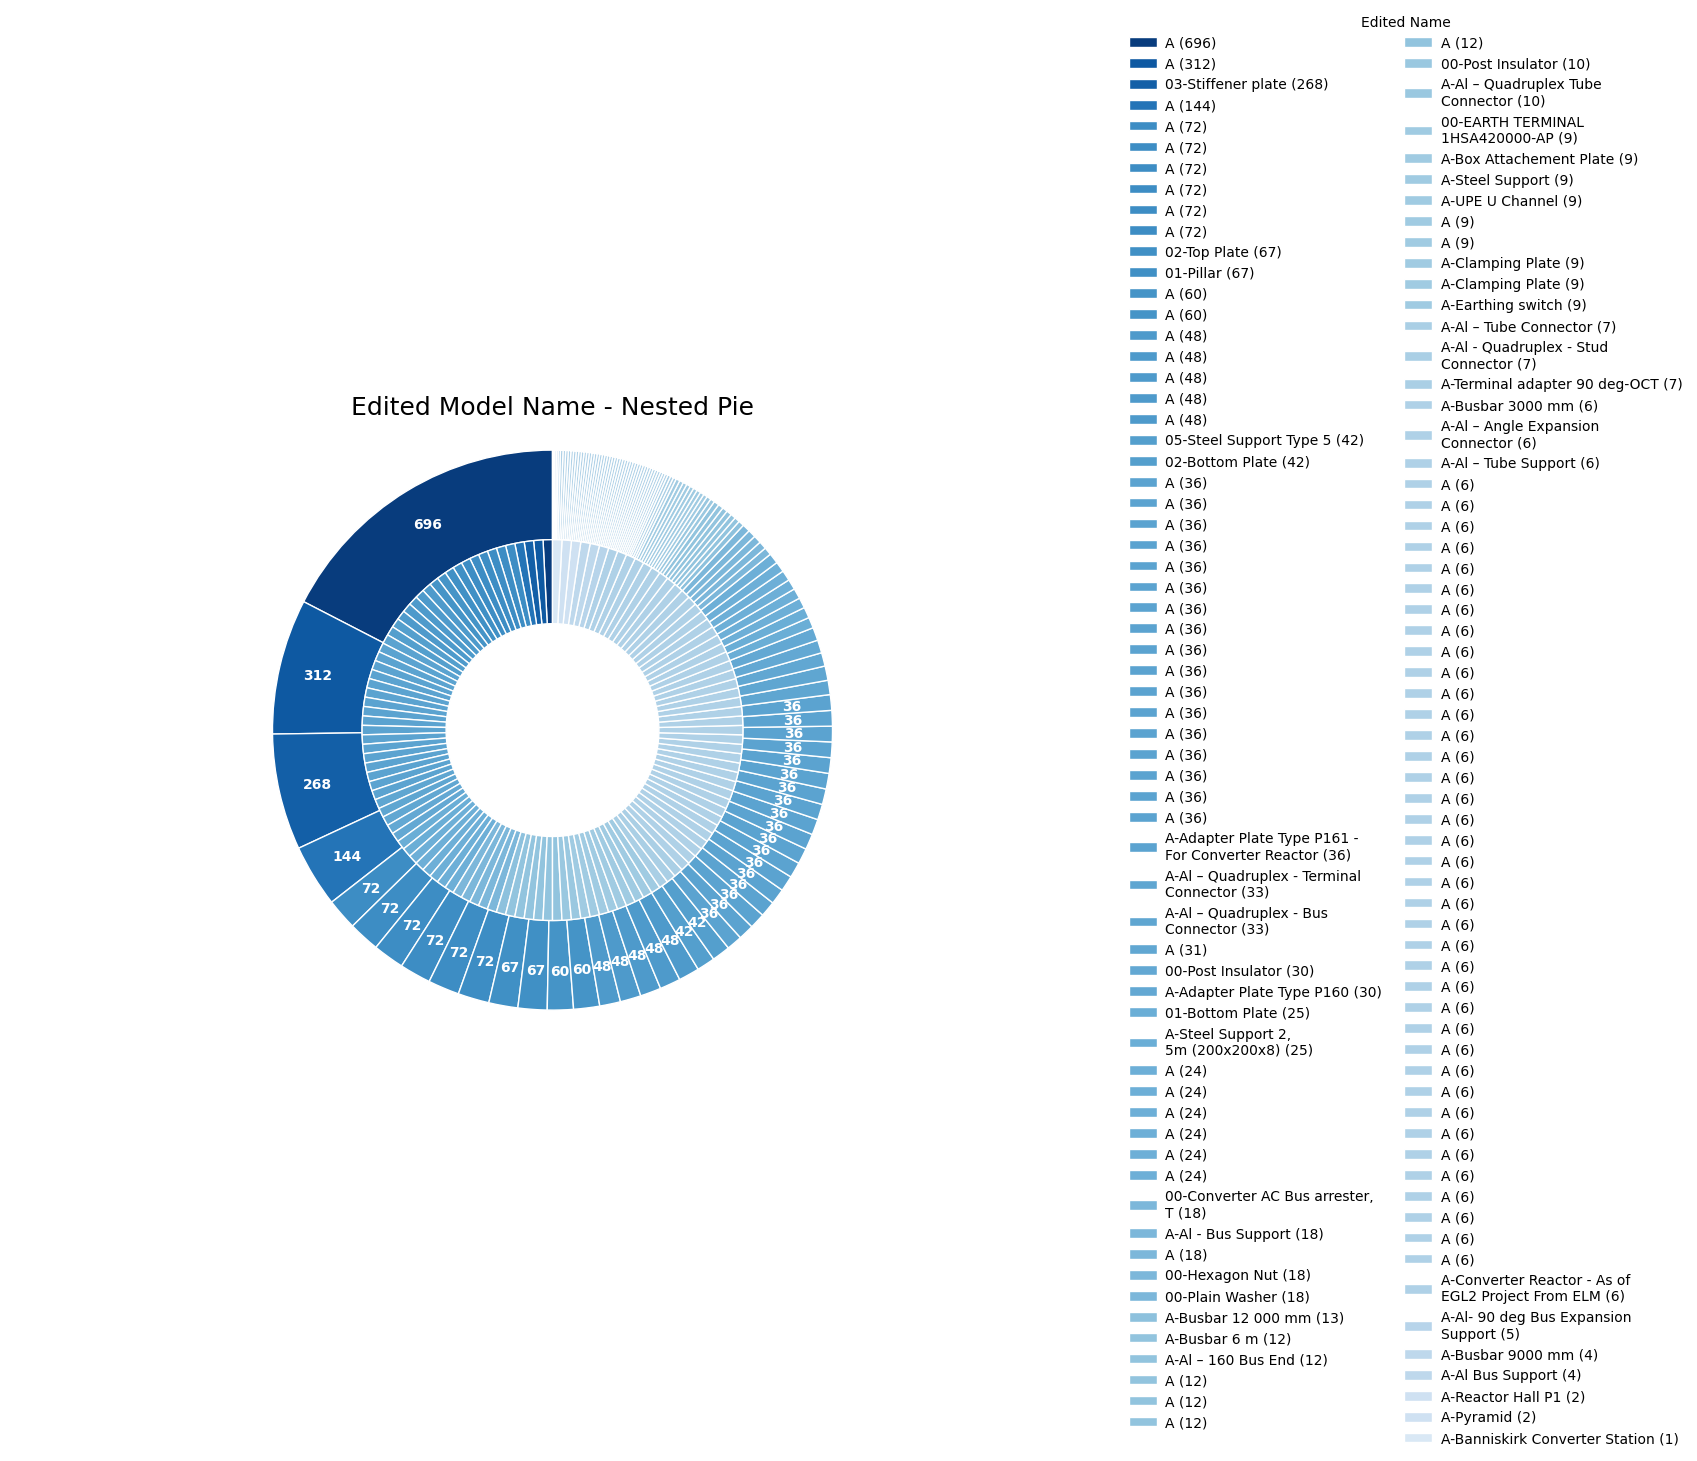

In [10]:
import matplotlib.pyplot as plt
import textwrap
import math

if "comparison_df" not in globals() or comparison_df.empty:
    print("No data available. Run Cell 3 first.")
else:
    chart_df = comparison_df[["Edited Name", "Count"]].copy()
    chart_df["Count"] = chart_df["Count"].fillna(0).astype(int)
    chart_df = chart_df.sort_values("Count", ascending=False).reset_index(drop=True)

    min_count = chart_df["Count"].min()
    max_count = chart_df["Count"].max()

    # Smoother color separation using log scaling so small categories are not all near-identical.
    if max_count == min_count:
        normalized = [0.6] * len(chart_df)
    else:
        log_min = math.log1p(min_count)
        log_max = math.log1p(max_count)
        normalized = (chart_df["Count"].apply(math.log1p) - log_min) / (log_max - log_min)

    blues_cmap = plt.get_cmap("Blues")
    colors = [blues_cmap(0.15 + 0.80 * n) for n in normalized]

    # Nested pie setup:
    # - Inner ring uses equal slices for each name.
    # - Outer ring uses actual counts; larger counts get larger outer slices.
    inner_values = [1] * len(chart_df)
    outer_values = chart_df["Count"].tolist()
    total_outer = sum(outer_values)

    label_threshold = 36

    def _outer_autopct(pct):
        count = int(round(pct * total_outer / 100.0))
        return f"{count}" if count >= label_threshold else ""

    def _wrap_name(name, max_chars=30):
        parts = [p.strip() for p in str(name).split(",") if p.strip()]
        if len(parts) <= 1:
            return "\n".join(textwrap.wrap(str(name), width=max_chars))

        lines = []
        current = ""
        for part in parts:
            candidate = f"{current}, {part}" if current else part
            if len(candidate) <= max_chars:
                current = candidate
            else:
                if current:
                    lines.append(current + ",")
                current = part
        if current:
            lines.append(current)
        return "\n".join(lines)

    fig, ax = plt.subplots(figsize=(14, 8))

    # Outer ring (count-driven)
    outer_pie = ax.pie(
        outer_values,
        radius=1.0,
        labels=None,
        colors=colors,
        startangle=90,
        autopct=_outer_autopct,
        pctdistance=0.86,
        wedgeprops={"width": 0.32, "edgecolor": "white", "linewidth": 1},
    )
    outer_wedges = outer_pie[0]
    outer_autotexts = outer_pie[2] if len(outer_pie) > 2 else []

    # Inner ring (same names/colors)
    ax.pie(
        inner_values,
        radius=0.68,
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={"width": 0.30, "edgecolor": "white", "linewidth": 1},
    )

    ax.set_title("Edited Model Name - Nested Pie", fontsize=18)
    ax.axis("equal")

    legend_labels = [
        f"{_wrap_name(name)} ({count})" for name, count in zip(chart_df["Edited Name"], chart_df["Count"])
    ]
    ax.legend(
        outer_wedges,
        legend_labels,
        title="Edited Name",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=2,
        columnspacing=1.6,
        handletextpad=0.6,
        frameon=False,
    )

    for autotext in outer_autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

## Hierarchical Bubble (Circle Packing)

This chart uses circle packing logic similar to your example:
- Large bubbles: `Edited Name` groups
- Small bubbles inside: `Existing Model Name` converted into each group
- Bubble size: conversion count

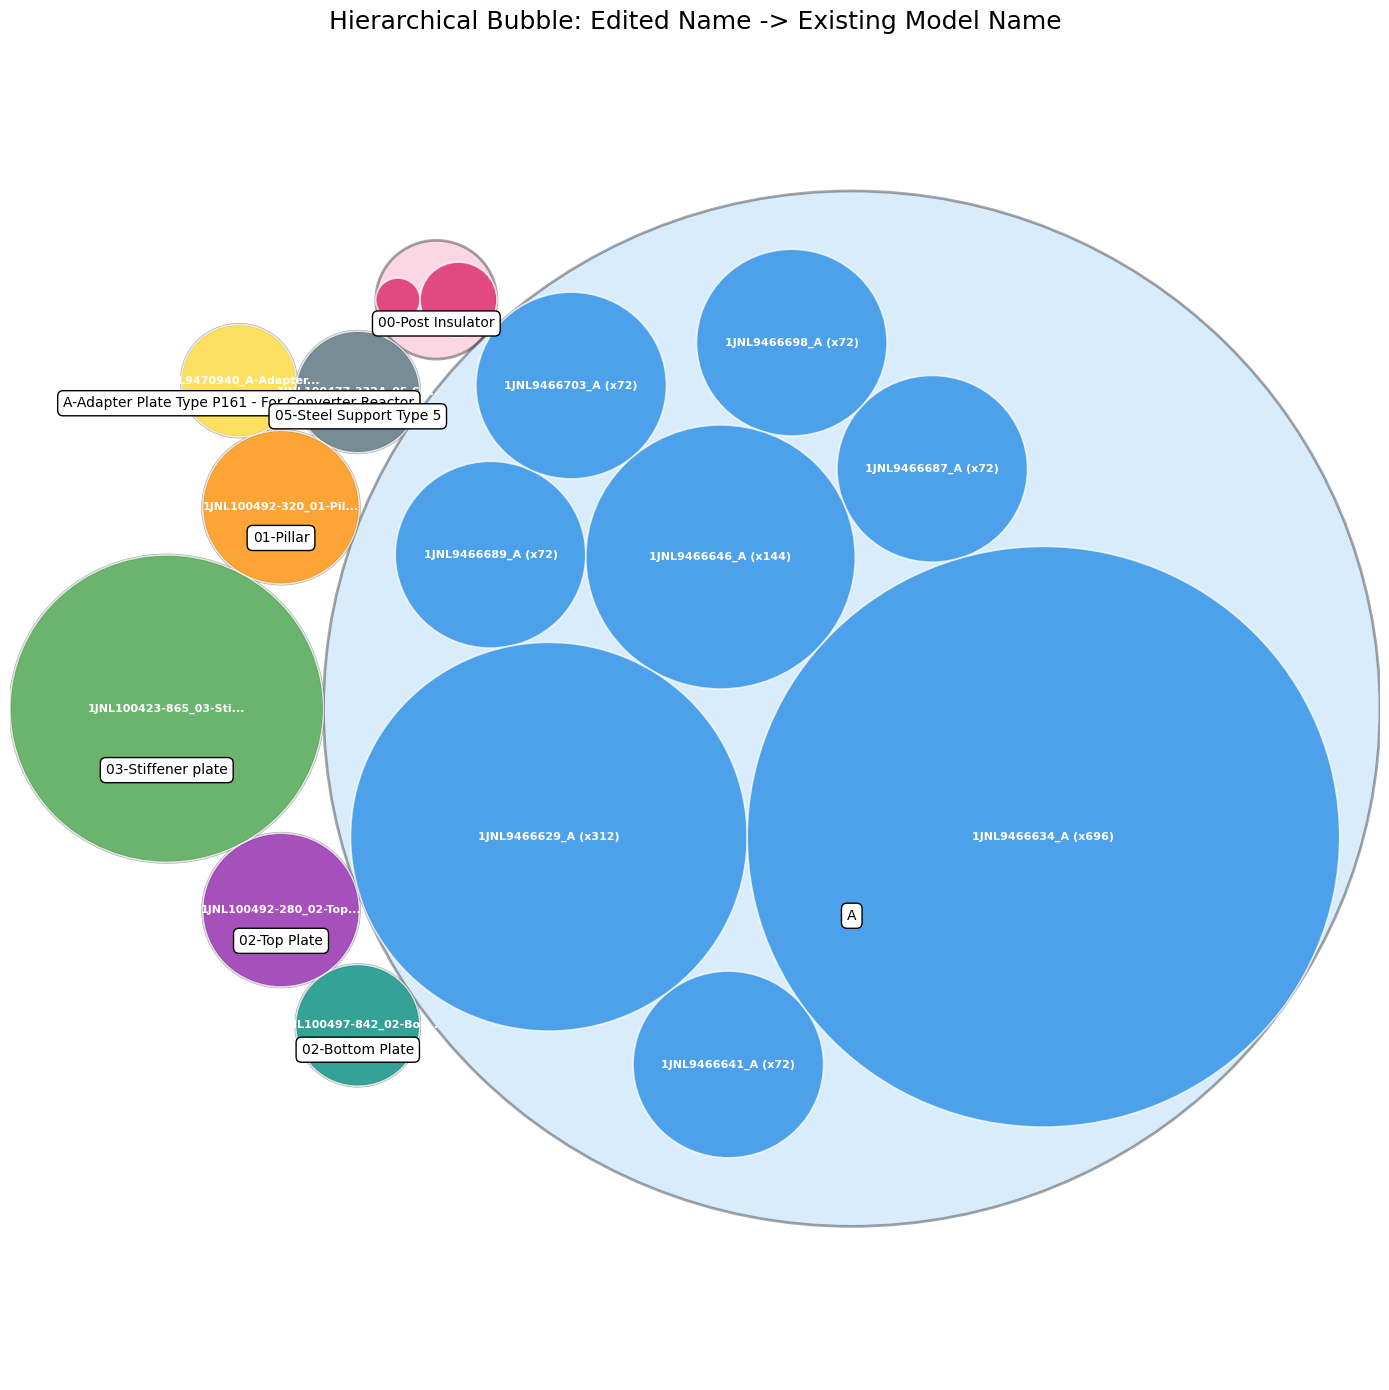

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    import circlify
except ImportError:
    print("Package 'circlify' is not installed. Run: %pip install circlify")
else:
    if "rows" not in globals() or len(rows) == 0:
        print("No data available. Run Cell 3 first.")
    else:
        hierarchy_df = pd.DataFrame(rows)

        grouped = (
            hierarchy_df.groupby(["Edited Name", "Existing Model Name"], dropna=False)
            .size()
            .rename("Count")
            .reset_index()
        )

        grouped["Edited Name"] = grouped["Edited Name"].fillna("(Unknown Group)")
        grouped["Existing Model Name"] = grouped["Existing Model Name"].fillna("(Unknown)")

        parent_totals = (
            grouped.groupby("Edited Name", dropna=False)["Count"]
            .sum()
            .sort_values(ascending=False)
        )

        top_group_n = 8
        top_child_n = 8
        selected_groups = parent_totals.head(top_group_n).index.tolist()

        if len(selected_groups) == 0:
            print("No hierarchical data to plot.")
        else:
            data_children = []
            for group_name in selected_groups:
                parent_count = int(parent_totals[group_name])
                sub = (
                    grouped[grouped["Edited Name"] == group_name]
                    .sort_values("Count", ascending=False, kind="stable")
                    .head(top_child_n)
                )

                child_nodes = [
                    {
                        "id": str(row["Existing Model Name"]),
                        "datum": int(row["Count"]),
                    }
                    for _, row in sub.iterrows()
                    if int(row["Count"]) > 0
                ]

                if child_nodes:
                    data_children.append(
                        {
                            "id": str(group_name),
                            "datum": parent_count,
                            "children": child_nodes,
                        }
                    )

            if not data_children:
                print("No child category data to plot.")
            else:
                root_total = sum(node["datum"] for node in data_children)
                data = [{"id": "Edited Model", "datum": root_total, "children": data_children}]

                circles = circlify.circlify(
                    data,
                    show_enclosure=False,
                    target_enclosure=circlify.Circle(x=0, y=0, r=1),
                )

                fig, ax = plt.subplots(figsize=(14, 14))
                ax.set_title("Hierarchical Bubble: Edited Name -> Existing Model Name", fontsize=18)
                ax.axis("off")

                lim = max(
                    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
                    for circle in circles
                )
                ax.set_xlim(-lim, lim)
                ax.set_ylim(-lim, lim)

                parent_palette = ["#90CAF9", "#A5D6A7", "#FFCC80", "#CE93D8", "#B0BEC5", "#80CBC4", "#F48FB1", "#FFF59D"]
                child_palette = ["#1E88E5", "#43A047", "#FB8C00", "#8E24AA", "#546E7A", "#00897B", "#D81B60", "#FDD835"]

                parent_color_map = {
                    name: parent_palette[i % len(parent_palette)]
                    for i, name in enumerate(selected_groups)
                }
                child_color_map = {
                    name: child_palette[i % len(child_palette)]
                    for i, name in enumerate(selected_groups)
                }

                for circle in circles:
                    if circle.level != 2:
                        continue
                    x, y, r = circle
                    group_name = circle.ex["id"]
                    ax.add_patch(
                        plt.Circle( # type: ignore
                            (x, y),
                            r,
                            alpha=0.35,
                            linewidth=2,
                            edgecolor="black",
                            facecolor=parent_color_map.get(group_name, "#B0BEC5"),
                        )
                    )

                for circle in circles:
                    if circle.level != 3:
                        continue
                    x, y, r = circle
                    child_label = str(circle.ex["id"])
                    child_count = int(circle.ex.get("datum", 0))

                    parent_name = None
                    for parent in circles:
                        if parent.level == 2 and (x - parent.x) ** 2 + (y - parent.y) ** 2 <= (parent.r ** 2):
                            parent_name = parent.ex["id"]
                            break

                    ax.add_patch(
                        plt.Circle( # type: ignore
                            (x, y),
                            r,
                            alpha=0.75,
                            linewidth=1.2,
                            edgecolor="white",
                            facecolor=child_color_map.get(parent_name, "#4DB6AC"),
                        )
                    )

                    if r > 0.06:
                        full_label = f"{child_label} (x{child_count})"
                        short_label = full_label if len(full_label) <= 24 else full_label[:21] + "..."
                        ax.annotate(
                            short_label,
                            (x, y),
                            ha="center",
                            va="center",
                            fontsize=8,
                            color="white",
                            weight="bold",
                        )

                for circle in circles:
                    if circle.level != 2:
                        continue
                    x, y, r = circle
                    group_label = str(circle.ex["id"])
                    label_y = y - (0.4 * r)
                    ax.annotate(
                        group_label,
                        (x, label_y),
                        va="center",
                        ha="center",
                        fontsize=10,
                        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "round", "pad": 0.4},
                    )

                plt.tight_layout()
                plt.show()